# Telecom Customer Churn Prediction

Author: Shannon Storts
  
---

## Executive Summary
This project analyzes the IBM Telco Customer Churn dataset to identify factors that influence whether customers leave their provider. Two classification models, Logistic Regression and K-Nearest Neighbors (KNN), were developed and compared. By testing with both 5-fold and 10-fold cross-validation, I found that Logistic Regression was the better model, hitting 78.75% testing accuracy with a Mean Accuracy of 80.69%. This extra testing shows the model is stable and isn't just overfitting, while KNN reached a peak of 77.68% after I tuned it to $k=12$. Based on the predictor coefficients, the analysis shows that customers with tenure and long-term contracts are the most likely to stay, while Fiber Optic service is the biggest risk factor associated with customers leaving. These findings can help businesses identify at-risk customers and improve retention strategies.

---

## Project Overview

This project uses the Telco Customer Churn dataset to predict whether a customer will leave a telecommunications company (Churn: Yes or No). The goal is to build a binary classification model that can help identify customers at risk of leaving.

Customer churn is a major concern for subscription-based businesses because losing customers directly impacts revenue. By identifying patterns in customer behavior, companies can take action early and improve retention.

The dataset contains information on over 7,000 customers, including account details, services used, and billing data. It includes both numerical and categorical features, making it a good example for real-world data preprocessing and modeling.

---

## Data Dictionary
The dataset contains 21 features related to customer demographics, services, and billing information.

**Demographic features:**
* `customerID`: unique identifier for each customer
* `gender`: whether the customer is male or female
* `SeniorCitizen`: indicates if the customer is a senior citizen (1 = Yes, 0 = No)
* `Partner`: whether the customer has a partner (Yes/No)
* `Dependents`: whether the customer has dependents (Yes/No)

**Account-related features:**
* `tenure`: number of months the customer has been with the company
* `PhoneService`: whether the customer has phone service (Yes/No)
* `MultipleLines`: whether the customer has multiple phone lines (Yes, No, or No phone service)

**Service-related features:**
* `InternetService`: type of internet service (DSL, Fiber optic, or None)
* `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,`StreamingTV`, `StreamingMovies`: technical services provided (Yes, No, or No internet service)

**Billing and contract features:**
* `Contract`: type of contract (Month-to-month, One year, Two year)
* `PaperlessBilling`: whether billing is paperless (Yes/No)
* `PaymentMethod`: method used for payment (Electronic check, Mailed check, Bank transfer, Credit card)

**Financial features:**
* `MonthlyCharges`: the customer’s current monthly bill
* `TotalCharges`: total amount charged over time (Note: converted to numeric to handle empty strings/missing values)

**Target variable:**
* `Churn`: whether the customer left the company (Yes/No; **prediction goal**)

---

## Data Loading
The dataset is loaded into a Pandas DataFrame, followed by an initial inspection of the first few rows, the total number of records, and the data types to understand the structure of the customer information.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


# Set visual style
sns.set_theme()
sns.set_style("white")

## Load dataset
telco_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
telco_df.head(8)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No


In [2]:
telco_df.shape

(7043, 21)

In [3]:
# check data types and basic info
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


`TotalCharges` is currently stored as an object (text),needs to be numeric

## Data Cleaning
Missing values are handled and unnecessary columns are removed to prepare the data for modeling.

In [4]:
## convert `TotalCharges` from 'object' to numeric data type

telco_df["TotalCharges"] = pd.to_numeric(telco_df["TotalCharges"], errors="coerce")


In [5]:
## check for missing values in each column

telco_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Notice there are **11** missing values in **TotalCharges**

In [6]:
## drop the 11 rows where TotalCharges was null
telco_df.dropna(subset=['TotalCharges'], inplace=True)

## drop customerID (P.K. not useful for prediction)
if 'customerID' in telco_df.columns:
    telco_df.drop('customerID', axis=1, inplace=True)

## verify final state
print(f"Final dataset shape: {telco_df.shape}")
print(f"Missing values remaining: {telco_df.isnull().sum().sum()}")

## view cleaned data
telco_df.head()



Final dataset shape: (7032, 20)
Missing values remaining: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The **customerID** column was removed, as it contains unique identifiers that do not contribute to predictive modeling.

## Exploratory Data Analysis
In this section, we investigate the dataset through statistical summaries and visualizations to uncover patterns, distributions, and relationships between features, particularly in relation to customer churn.

### Summary Statistics
We will start by looking at the summary statistics and distributions to get a feel for the data before diving into the visualizations

In [7]:
# get summary statistics for numerical columns
display(telco_df.describe())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


The Summary Statistics display a diverse customer base. The average tenure is 32 months, but the high standard deviation (std = 24.5) confirms we have a mix of long-term loyalists and brand-new users. Similarly, Monthly Charges show a wide range from 18.25 (USD) to 118.75 (USD). This spread suggests that both tenure and pricing are likely to be primary drivers of churn.

### Correlation Analysis
Next, we use a correlation heatmap to see how the numeric variables relate to each other and identify which features might be strong predictors for churn.

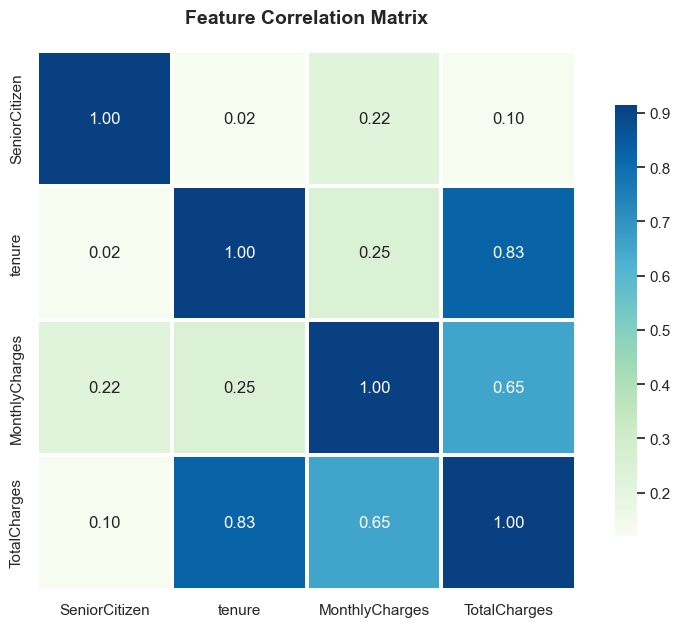

In [8]:
# Correlation Heatmap (numeric relationships)

plt.figure(figsize=(10, 7))

sns.heatmap(telco_df.corr(numeric_only=True), 
            annot=True, 
            fmt='.2f', 
            cmap='GnBu', 
            vmin=0.12, 
            vmax=0.915,
            linewidths=1.5, 
            linecolor='white',
            square=True,
            cbar_kws={"shrink": .8})

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.show()



The heatmap shows a high correlation (0.83) between tenure and TotalCharges. This is expected, as total costs naturally accumulate over time. To avoid using redundant data in the models, these two features will be monitored closely during the preprocessing and feature selection stages.

### Categorical Feature Overview
We use this table to get a quick look at the categorical features and see what the typical customer profile looks like.

In [9]:
## summary statistics for categorical columns
display(telco_df.describe(include='object'))

# summary statistics for categorical columns 
# Note: 6361/7043 = ~90% of customers have PhoneService

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


The categorical summary shows that the most frequent customer profile in this dataset is a male with no partner or dependents. Phone service is nearly universal, with over 90% of customers subscribed. Among internet options, Fiber Optic is the most common service type. A significant portion of the base is on month-to-month contracts and utilizes electronic checks for payment. These two traits are often associated with higher churn rates.

### Target Variable & Class Distribution
We need to see how balanced our target variable is, so we are looking at the breakdown of Churn 'Yes' vs 'No' here.

In [10]:
# calculate churn distribution (counts and percentages)

churn_counts = telco_df["Churn"].value_counts()
churn_percent = telco_df["Churn"].value_counts(normalize=True) * 100
churn_summary = pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percent
})

display(churn_summary)


,Count,Percentage
Churn,,
No,5163,73.421502
Yes,1869,26.578498


The data shows a 73.42% to 26.58% split between customers who stayed and those who left. Given this distribution, we will focus on optimizing the model to accurately detect the minority 'Churn' class, ensuring the final results aren't skewed by the larger group of retained customers.

### Churn Distribution

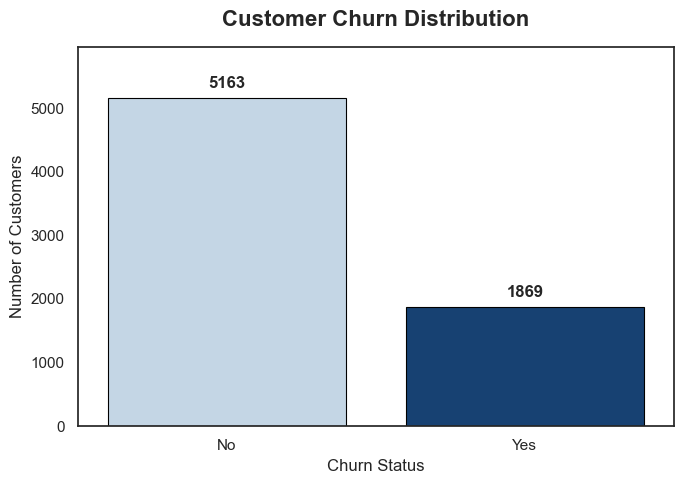

In [11]:
## Visualize the overall Churn Distribution

plt.figure(figsize=(7, 5))
ax = sns.countplot(
    x='Churn', 
    hue='Churn',
    data=telco_df, 
    #palette=['#BFD7EA', '#1F4E79'],
    palette=['#BFD7EA', '#084081'],
    edgecolor='black', 
    linewidth=0.8,
    legend=False
)

### value labels
for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold', fontsize=12)

plt.title('Customer Churn Distribution', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

## space at top 
plt.ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()


We observe a clear split: over 5,000 customers were retained, while approximately 1,900 left. This confirms that while the majority of customers stay, the churn group is large enough for us to identify the specific patterns and drivers behind why people are leaving.

### Contract Type vs Churn

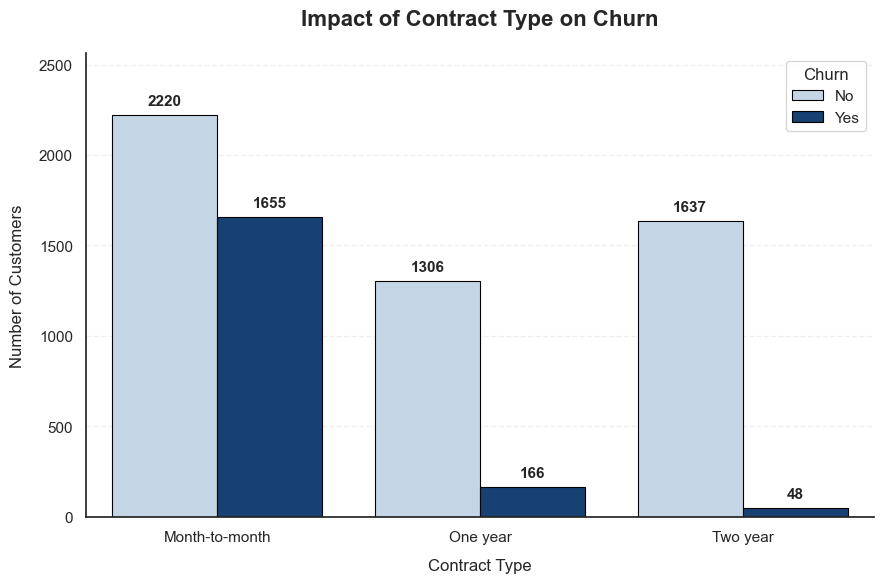

In [12]:
## visualize the Impact of Contract Type on Churn

plt.figure(figsize=(9, 6)) 
ax = sns.countplot(
    x='Contract', 
    hue='Churn', 
    data=telco_df, 
    palette=['#BFD7EA', '#084081'], 
    edgecolor='black', 
    linewidth=0.8
)

## add labels, pad , reduce font size 
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11, fontweight='bold')

plt.title('Impact of Contract Type on Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Contract Type', fontsize=12, labelpad=10)
plt.ylabel('Number of Customers', fontsize=12, labelpad=10)

## increase the y-axis limit
plt.ylim(0, ax.get_ylim()[1] * 1.1) 

plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()



The data shows that stability comes with longer commitments. While month-to-month plans are high-risk with over 1,650 churn cases, the numbers drop drastically for long-term contracts. One-year contracts see significantly fewer departures, and two-year contracts have almost negligible churn with only 48 cases.

### Tenure vs Churn

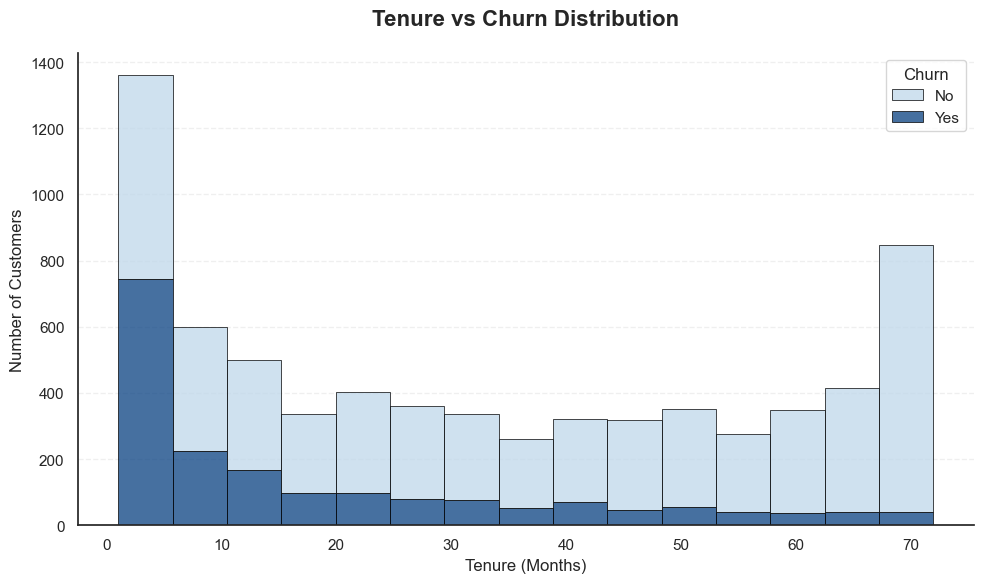

In [13]:
## visualize Tenure vs Churn
plt.figure(figsize=(10, 6))
sns.histplot(
    data=telco_df, 
    x='tenure', 
    hue='Churn', 
    multiple="stack", 
    palette=['#BFD7EA', '#084081'], 
    edgecolor='black', 
    linewidth=0.5,
    hue_order=['No', 'Yes'] 
)

plt.title('Tenure vs Churn Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()



The distribution shows a high concentration of churn within the first 6 months of service. However, the risk drops significantly after the first year, and for customers who reach the 5-year (60+ month) mark, churn becomes almost non-existent. This indicates a strong inverse relationship between tenure and churn, where the probability of a customer leaving decreases the longer they remain with the service.

### Monthly Charges vs Churn

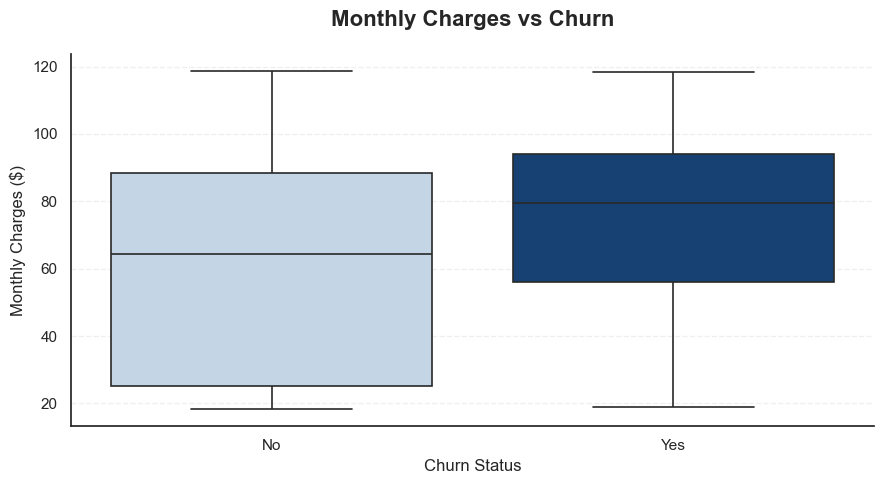

In [14]:
## visualize monthly charges vs churn
plt.figure(figsize=(9, 5))
sns.boxplot(
    x='Churn', 
    y='MonthlyCharges', 
    hue='Churn', 
    data=telco_df, 
    palette=['#BFD7EA', '#084081'], 
    linewidth=1.2,
    fliersize=4, 
    legend=False
)

plt.title('Monthly Charges vs Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Monthly Charges ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()




The boxplot shows that customers who left generally had higher bills. Their median monthly charge is around 80 dollars, while the median for customers who stayed is lower, at about 64 dollars. Most of the churned group is packed into the higher price range between 70 and 95 dollars, whereas the retained group is spread out more evenly across all costs. This suggests that as monthly charges go up, we see a lot more customers leaving.

### Internet Service vs Churn

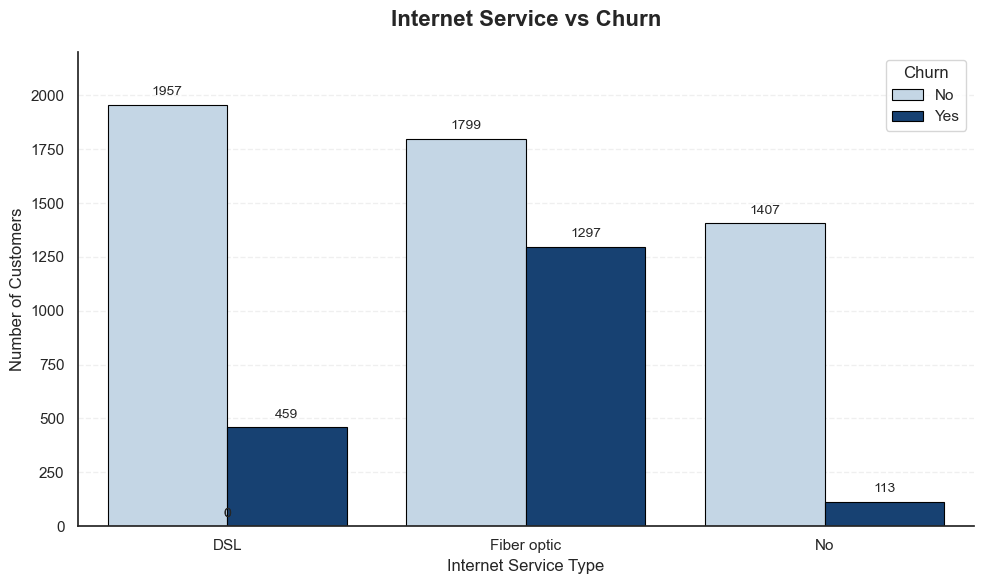

In [15]:
## visualize internet vs churn

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    x='InternetService', 
    hue='Churn', 
    data=telco_df, 
    palette=['#BFD7EA', '#084081'], 
    edgecolor='black', 
    linewidth=0.8
)

## value labels top 
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10)

plt.title('Internet Service vs Churn', fontsize=16, fontweight='bold', pad=19)
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.ylim(0, 2200) 
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()



Our analysis shows that Fiber Optic users have the highest volume of churn, with 1,297 customers leaving compared to 1,799 who stayed. In contrast, DSL users are much more stable, with only 459 leaving and nearly 2,000 staying. Customers with no internet service at all show the lowest churn rates. This shows that the type of internet service is a major factor in whether a customer stays or leaves.

## **Model Development**
In this section, the dataset is prepared and used to build machine learning models that predict whether a customer will churn.

### Data Preprocessing
We prepare the data by removing unique identifiers, encoding the target variable into numerical format, and converting categorical features into dummy variables.

In [16]:
### separate features (X) and target variable (y)
##customerID was removed from telco_df 
df_modeling = telco_df.copy()

## define features (X) and target variable (y)
X = df_modeling.drop(columns=['Churn'])
y = df_modeling['Churn']

## encode target: Convert 'Yes'/'No' to 1/0 (Label Encoding)
y = y.map({'Yes': 1, 'No': 0})

##convert categorical text to binary scale (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

## verify data
print(f"Features prepared. Total columns: {X.shape[1]}")
X.head()




Features prepared. Total columns: 30


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


### Train-Test Split 
The data is split into 80% for training the model and 20% for testing the results.

In [17]:
## split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## verify split 
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")


Training set size: (5625, 30)
Testing set size: (1407, 30)


### Feature Scaling
Standard scaling is applied to the features to ensure they are on the same scale for the model.

In [18]:
###initialize the scaler
scaler = StandardScaler()

## fit and transform the training data
## transform the test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## verify the scaled data shape
print("Feature scaling complete.")
print(f"Scaled Training Shape: {X_train_scaled.shape}")
print(f"Scaled Testing Shape: {X_test_scaled.shape}")


Feature scaling complete.
Scaled Training Shape: (5625, 30)
Scaled Testing Shape: (1407, 30)


### Logistic Regression Model
The model is fitted to the training data to generate churn predictions.

In [19]:
## create the model & setup coef/intercept container
## using maximum likelihood estimation (MLE) to find the optimal log-odds
log_model = LogisticRegression(max_iter=1000)

## train model: MLE & Solver iterate to find best parameters (coef/intercept)
log_model.fit(X_train_scaled, y_train)

## make predictions
y_pred_log = log_model.predict(X_test_scaled)

### Logistic Regression: Performance & Evaluation
The model's performance is evaluated by comparing the training accuracy to the testing accuracy and analyzing the confusion matrix results.

Logistic Regression Training Accuracy: 0.8085
Logistic Regression Testing Accuracy: 0.7875


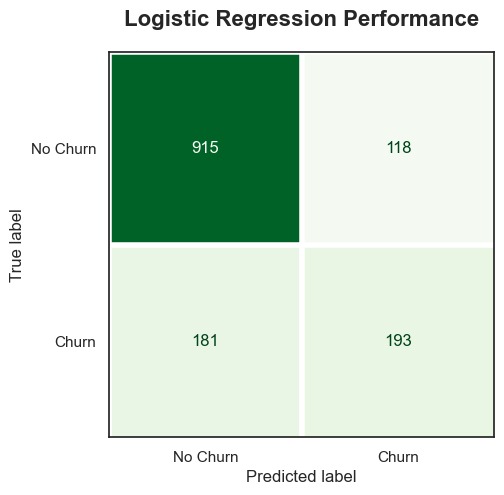

In [20]:
###print training and testing accuracy for 'Logistic Regression'
print(f"Logistic Regression Training Accuracy: {log_model.score(X_train_scaled, y_train):.4f}")
print(f"Logistic Regression Testing Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")


##create the confusion matrix
confM = confusion_matrix(y_test, y_pred_log)

### display
fig, ax = plt.subplots(figsize=(8, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=confM, display_labels=['No Churn', 'Churn'])

# plot 
disp.plot(cmap='Greens', ax=ax, values_format='d', colorbar=False, im_kw={'vmin': 100, 'vmax': 1000})

# add white separators
ax.set_xticks(np.arange(2)-.5, minor=True)
ax.set_yticks(np.arange(2)-.5, minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=4)
ax.tick_params(which="minor", bottom=False, left=False)

plt.title('Logistic Regression Performance', fontweight='bold', pad=19, fontsize=16)
plt.show()



In [21]:
# show results as a table
pd.crosstab(y_test, y_pred_log)

col_0,0,1
Churn,,
0,915,118
1,181,193


In [22]:
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_log))

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



**Section Summary:** The Logistic Regression model yielded a testing accuracy of 78.75% and a training accuracy of 80.85%. Because these values are closely aligned, the model demonstrates good generalization and shows no indication of overfitting. Looking at the performance breakdown, the model correctly identified 915 non-churn customers and 193 customers who left. While the model is highly effective at identifying customers who stay, it has more difficulty predicting those who actually leave, misclassifying 181 churners as staying.

### K-Nearest Neighbors Model

#### Initial Model Training (Baseline: $k = 5$)
The KNN model is initialized with a standard baseline of $k=5$ and fitted to the training data to establish initial performance metrics.

In [23]:
## create the initial/baseline model (k = 5)
knn_initial_model = KNeighborsClassifier(n_neighbors=5)

## train model
knn_initial_model.fit(X_train_scaled, y_train)

## predictions
y_pred_knn = knn_initial_model.predict(X_test_scaled)

#### Initial KNN Evaluation ($k = 5$)

In [24]:
## print training and testing accuracy
## calculate scores
train_acc = knn_initial_model.score(X_train_scaled, y_train)
test_acc = accuracy_score(y_test, y_pred_knn)

print(f"Initial KNN Training Accuracy: {train_acc:.2%}")
print(f"Initial KNN Testing Accuracy:  {test_acc:.2%}")

## confusion Matrix
print("\nConfusion Matrix:")
confM_knn = confusion_matrix(y_test, y_pred_knn)
print(confM_knn)


Initial KNN Training Accuracy: 83.79%
Initial KNN Testing Accuracy:  75.27%

Confusion Matrix:
[[869 164]
 [184 190]]


In [25]:
print("\n--- Initial KNN Classification Report ($k=5$) ---")
print(classification_report(y_test, y_pred_knn))


--- Initial KNN Classification Report ($k=5$) ---
              precision    recall  f1-score   support

           0       0.83      0.84      0.83      1033
           1       0.54      0.51      0.52       374

    accuracy                           0.75      1407
   macro avg       0.68      0.67      0.68      1407
weighted avg       0.75      0.75      0.75      1407



In [26]:
pd.crosstab(y_test, y_pred_knn)

col_0,0,1
Churn,,
0,869,164
1,184,190


**Section Summary:** The initial KNN model ($k=5$) correctly identified 869 customers who stayed and 190 customers who churned. However, the model failed to catch 184 customers who actually left the company. A significant gap exists between the training accuracy (83.79%) and testing accuracy (75.27%). This performance difference indicates that $k=5$ causes the model to overfit the training data. To improve the model's ability to generalize to new customers, hyperparameter tuning is required to find a more optimal $k$ value.

### Find the Best $k$ Value: Hyperparameter Tuning

To identify the optimal model, we evaluate $k$ values from 1 to 20 to find the best balance between training and testing accuracy.

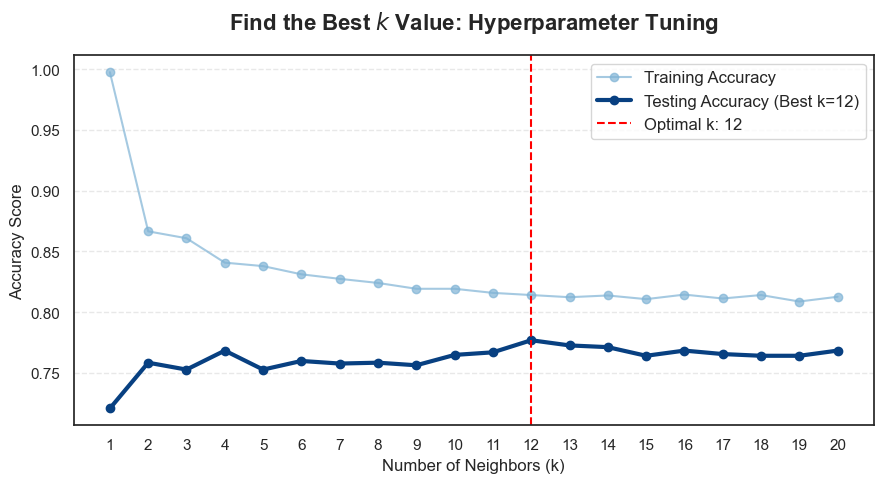

The Best k is: k = 12 with 0.7768 accuracy.


In [27]:
#test different values of k
##Initialize range and empty lists for scores
k_values = range(1, 21)
train_scores = []
test_scores = []


## iterate through k values 
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

    
## find optimal k
best_k = k_values[test_scores.index(max(test_scores))]


## plotting results
plt.figure(figsize=(9, 5))
plt.plot(k_values, train_scores, marker='o', label='Training Accuracy', color='#7FB3D5', alpha=0.7)
plt.plot(k_values, test_scores, marker='o', label=f'Testing Accuracy (Best k={best_k})', color='#084081', linewidth=3)

## add a vertical line and highlight "best k"
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Optimal k: {best_k}')

#Formatting graph
plt.title('Find the Best $k$ Value: Hyperparameter Tuning', fontsize=16, fontweight='bold', pad=19)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(k_values)
plt.legend(loc='upper right', fontsize=12, frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.45)

plt.tight_layout()
plt.show()



print(f"The Best k is: k = {best_k} with {max(test_scores):.4f} accuracy.")


The testing accuracy reaches its peak at $k=12$ with 77.68% accuracy. This value provides the best generalization for the model and will be used for the final KNN evaluation.

### KNN Model with Best $k$
The model is re-trained using the optimal $k=12$ value identified during hyperparameter tuning to ensure the best possible performance on unseen data.

In [28]:
##creating KNN model using best k
knn_final = KNeighborsClassifier(n_neighbors=best_k)

##train model
knn_final.fit(X_train_scaled, y_train)

## make predictions
y_pred_knn_final = knn_final.predict(X_test_scaled)



### K-Nearest Neighbors: Performance & Evaluation
The optimized model is evaluated using a confusion matrix and classification report to determine its effectiveness in predicting customer churn.

Final Training Accuracy: 0.8140
Final Testing Accuracy: 0.7768


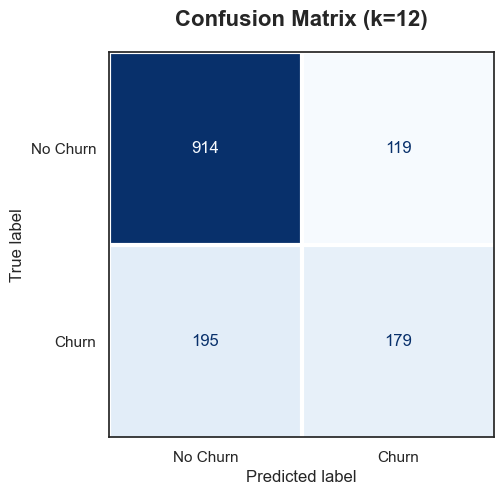

In [29]:
## print training and testing accuracy
print(f"Final Training Accuracy: {knn_final.score(X_train_scaled, y_train):.4f}")
print(f"Final Testing Accuracy: {accuracy_score(y_test, y_pred_knn_final):.4f}")


## create the visual matrix
fig, ax = plt.subplots(figsize=(8, 5))
cmd = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_knn_final, 
    display_labels=['No Churn', 'Churn'],
    cmap='Blues', 
    ax=ax,
    colorbar=False,
    im_kw={'vmin': 115, 'vmax': 900}
)

## adding white grid lines
ax.set_xticks(np.arange(2)-.5, minor=True)
ax.set_yticks(np.arange(2)-.5, minor=True)
ax.grid(which="minor", color="white", linestyle='-', linewidth=3)
ax.tick_params(which="minor", bottom=False, left=False)

plt.title(f'Confusion Matrix (k={best_k})', fontweight='bold',fontsize=16, pad=19)
plt.show()



In [30]:
print("\n--- Final KNN Classification Report (k=12) ---")
print(classification_report(y_test, y_pred_knn_final))


--- Final KNN Classification Report (k=12) ---
              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.60      0.48      0.53       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.78      0.77      1407



In [31]:
pd.crosstab(y_test, y_pred_knn_final)

col_0,0,1
Churn,,
0,914,119
1,195,179


**Section Summary:** The final KNN model $(k=12)$ achieved a 77.68% testing accuracy. As shown in the confusion matrix, it correctly identified 914 customers who stayed and 179 who churned, but missed 195 customers who actually churned. This performance is likely limited by the moderate class imbalance in the dataset, as the model sees significantly more examples of non-churning customers during training.

## Logistic Model Validation & Predictor Analysis
This section confirms the reliability of the Logistic Regression model results through cross-validation and examines the specific variables that influence the model's predictions.

### k-fold Cross-Validation

This step verifies that the model's accuracy remains consistent across different subsets of the training data.

In [32]:
## 5-fold cross-validation on the top Logistic Regression model
cv_scores = cross_val_score(log_model, X_train_scaled, y_train, cv=5)

print("=" * 40)
print("   5-FOLD CROSS-VALIDATION RESULTS   ")
print("=" * 40)
print(f"Individual Fold Scores:{cv_scores.round(4)}")
print(f"Mean CV Accuracy:       {cv_scores.mean():.4f}")
print(f"Standard Deviation:     {cv_scores.std():.4f}")
print(f"Model Stability Check: Pass (Std Dev {cv_scores.std():.4f} is low)")

   5-FOLD CROSS-VALIDATION RESULTS   
Individual Fold Scores:[0.8187 0.8071 0.7911 0.7973 0.8204]
Mean CV Accuracy:       0.8069
Standard Deviation:     0.0115
Model Stability Check: Pass (Std Dev 0.0115 is low)


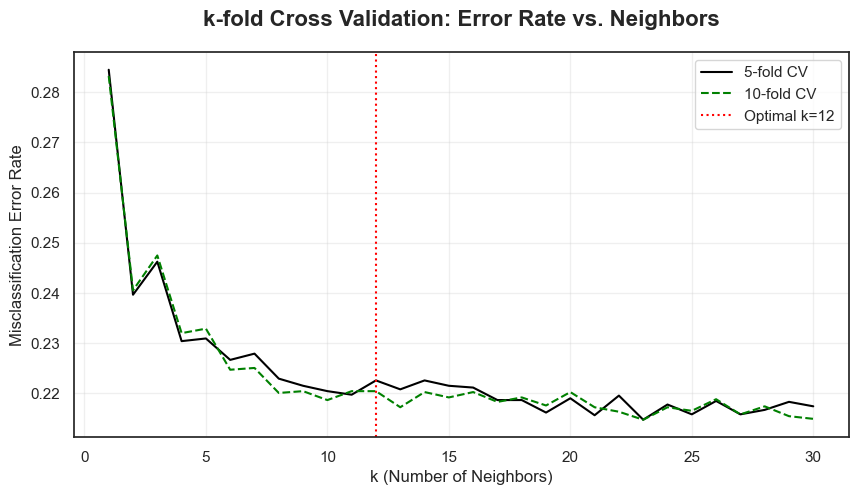

In [33]:
## define range
k_neighbors = range(1, 31)
error_5fold = []
error_10fold = []

## 5-fold and 10-fold forloop
for k in k_neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    ## 5-fold 
    score5 = cross_val_score(knn, X_train, y_train, cv=5)
    error_5fold.append(1 - score5.mean())
    
    ## 10-fold 
    score10 = cross_val_score(knn, X_train, y_train, cv=10)
    error_10fold.append(1 - score10.mean())

### plot
plt.figure(figsize=(10, 5))
plt.plot(k_neighbors, error_5fold, color='black', label='5-fold CV')
plt.plot(k_neighbors, error_10fold, color='green', label='10-fold CV', linestyle='--')


plt.title('k-fold Cross Validation: Error Rate vs. Neighbors', fontsize=16, fontweight='bold', pad=19)
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Misclassification Error Rate')
plt.axvline(12, color='red', linestyle=':', label='Optimal k=12') 
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Predictor Coefficients
This table shows the mathematical weights of the features to see which ones have the most impact on customer churn.

In [34]:
## extracting the coefficients from the 'Logistic Regression model'
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})

## sorting by absolute value 
##predictors desc
coef_df['Absolute_Weight'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Absolute_Weight', ascending=False)

## churn title bar
title = "     Top 10 Predictors of Churn      "
print("=" * len(title))
print(title)
print("=" * len(title))


display(coef_df[['Feature', 'Coefficient']].head(10))



     Top 10 Predictors of Churn      


,Feature,Coefficient
1,tenure,-1.445747
3,TotalCharges,0.694885
10,InternetService_Fiber optic,0.650749
2,MonthlyCharges,-0.632801
25,Contract_Two year,-0.567396
24,Contract_One year,-0.314562
23,StreamingMovies_Yes,0.222440
21,StreamingTV_Yes,0.212963
9,MultipleLines_Yes,0.160546
13,OnlineSecurity_Yes,-0.155520


**Section Summary:** The k-fold cross-validation (k=5 and k=10) demonstrates that the model is stable across different data splits, achieving a mean accuracy of 80.69%. Performance is optimized at k = 12, effectively balancing the bias-variance tradeoff. Based on the model coefficients, tenure is the most influential predictor, showing that longer customer relationships significantly reduce the likelihood of churn, while long-term contracts further support retention. Among the positive predictors, TotalCharges has the strongest effect, followed closely by Fiber Optic internet service, both of which are associated with an increased likelihood of churn.

---
## Final Conclusion & Model Comparison

This project analyzed customer churn using the Telco dataset, identifying contract type, internet service type, and tenure as the primary drivers of customer loss. To address this, we developed and compared two models:

| Metric | Logistic Regression | K-Nearest Neighbors ($k=12$) |
| :--- | :--- | :--- |
| **Testing Accuracy** | **78.75%** | 77.68% |
| **Recall (Churn)** | **0.52** | 0.48 |

Based on the analysis, Logistic Regression is the superior model for this dataset. Not only did it achieve the highest overall accuracy (78.75%), but it also provided a better Recall score (0.52), meaning it is more effective at identifying customers who are at risk of canceling service.

Compared to KNN, Logistic Regression is the better choice because it shows exactly which factors are causing customers to leave, whereas KNN acts more as a "black box" that is less transparent regarding its internal logic. The results show that Fiber Optic service and month-to-month contracts are the primary reasons for churn.

However, the 0.52 Recall is a real limitation to keep in mind; it means the model still misses about half of the people who actually leave. By focusing on these specific high-risk areas rather than just the overall accuracy, the business can better address the known causes of turnover and work on better ways to keep those customers.



---
## Data Source

- [Telco Customer Churn Dataset (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

This dataset is based on IBM sample data and includes customer demographics, account information, services, and billing details.
